# Spicy 1 Copy Mechanism

In [20]:
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import nltk
from nltk.tokenize import word_tokenize
import random
import copy
import csv
import ast

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

nltk.download('punkt_tab')
print(device)
print(f"seed={SEED}")

mps
seed=42


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kaichen/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [21]:
data_dir = Path.cwd() / "Cooking_Dataset"
if data_dir.exists():
    os.chdir(data_dir)
print(Path.cwd())

/Users/kaichen/Desktop/MONASH/FIT5217/Assignment 2/Cooking_Dataset


In [22]:
SOS_token = 0
EOS_token = 1
UNK_token = 2


class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS", 2: "UNK"}
        self.n_words = 3  # Count SOS, EOS, UNK

    def addSentence(self, sentence):
        for word in nltk.word_tokenize(sentence):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [23]:
def normalizeRecipeString(s):
    return s.lower().strip()

In [24]:
def readRecipePairs(csv_path):
    pairs = []

    with open(csv_path, 'r', encoding='utf-8') as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                ing_list = ast.literal_eval(row['Ingredients'])
                recipe_steps = ast.literal_eval(row['Recipe'])

                ing_text = ", ".join(ing_list)
                recipe_text = " ".join(recipe_steps).strip()
                pairs.append((ing_text, recipe_text))

            except Exception:
                print("Skip one data row: ", row)
                continue

    return pairs

def buildLangsFromPairs(pairs):
    input_lang = Lang("ingredients")
    output_lang = Lang("recipes")

    for ingre, recipe in pairs:
        input_lang.addSentence(normalizeRecipeString(ingre))
        output_lang.addSentence(normalizeRecipeString(recipe))

    return input_lang, output_lang

def readRecipe(csv_path):
    pairs = readRecipePairs(csv_path)
    input_lang, output_lang = buildLangsFromPairs(pairs)
    return input_lang, output_lang, pairs


In [25]:
MAX_INPUT_LEN = 50
MAX_OUTPUT_LEN = 100

def filter(pair):
    input_len = len(nltk.word_tokenize(pair[0]))
    output_len = len(nltk.word_tokenize(pair[1]))
    return input_len <= MAX_INPUT_LEN and output_len <= MAX_OUTPUT_LEN

def filterPairs(pairs):
    return [p for p in pairs if filter(p)]

In [26]:
TRAIN_SAMPLE_SIZE = 60000
SHORT_RECIPE_FRACTION = 0.65
DEV_SAMPLE_SIZE = 1065

def pair_lengths(pair):
    input_len = len(word_tokenize(pair[0]))
    output_len = len(word_tokenize(pair[1]))
    return input_len, output_len

def select_training_pairs(pairs, max_samples=TRAIN_SAMPLE_SIZE, short_fraction=SHORT_RECIPE_FRACTION):
    if len(pairs) <= max_samples:
        return pairs

    scored_pairs = []
    for pair in pairs:
        input_len, output_len = pair_lengths(pair)
        scored_pairs.append(((input_len + output_len, output_len, input_len), pair))

    scored_pairs.sort(key=lambda x: x[0])
    sorted_pairs = [pair for _, pair in scored_pairs]

    easy_pool_size = min(len(sorted_pairs), max_samples * 3)
    short_count = min(int(max_samples * short_fraction), easy_pool_size)
    selected = []

    if short_count > 0:
        selected.extend(random.sample(sorted_pairs[:easy_pool_size], short_count))

    selected_set = set(selected)
    remaining_pool = [pair for pair in sorted_pairs if pair not in selected_set]
    remaining_needed = max_samples - len(selected)
    if remaining_needed > 0:
        selected.extend(random.sample(remaining_pool, remaining_needed))

    random.shuffle(selected)
    return selected

def prepareRecipeData(csv_path, max_samples=TRAIN_SAMPLE_SIZE, short_fraction=SHORT_RECIPE_FRACTION):
    all_pairs = readRecipePairs(csv_path)
    filtered_pairs = filterPairs(all_pairs)
    print("Samples after filtration:", len(filtered_pairs))

    pairs = select_training_pairs(filtered_pairs, max_samples=max_samples, short_fraction=short_fraction)
    input_lang, output_lang = buildLangsFromPairs(pairs)

    avg_input_len = sum(pair_lengths(pair)[0] for pair in pairs) / len(pairs)
    avg_output_len = sum(pair_lengths(pair)[1] for pair in pairs) / len(pairs)
    print("Cutoff Samples:", len(pairs))
    print("Read %s samples" % len(pairs))
    print(f"Average lengths: input={avg_input_len:.1f}, output={avg_output_len:.1f}")
    print("Input vocabulary: ", input_lang.n_words)
    print("Output vocabulary: ", output_lang.n_words)
    return input_lang, output_lang, pairs

input_lang, output_lang, pairs = prepareRecipeData("train.csv")
print(random.choice(pairs))


Samples after filtration: 112441
Cutoff Samples: 60000
Read 60000 samples
Average lengths: input=33.3, output=40.0
Input vocabulary:  6651
Output vocabulary:  10038
('1 pie crust, 1 1/2 c. thinly sliced raw potatoes, salt and pepper to taste, 1 c. cubed rump roast or sirloin steak *, 1 small thinly sliced onion', 'Note: Ingredients listed are for each pastie.')


In [27]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=2, dropout_p=0.2):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_directions = 2

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.embedding_dropout = nn.Dropout(dropout_p)
        self.gru = nn.GRU(
            hidden_size,
            hidden_size,
            num_layers=num_layers,
            dropout=dropout_p if num_layers > 1 else 0.0,
            bidirectional=True,
        )
        self.output_proj = nn.Linear(hidden_size * self.num_directions, hidden_size)
        self.hidden_proj = nn.Linear(hidden_size * self.num_directions, hidden_size)
        self.layer_norm = nn.LayerNorm(hidden_size)

    def forward(self, input, hidden):
        embedded = self.embedding(input).view(1, 1, -1)
        embedded = self.embedding_dropout(embedded)
        output, hidden = self.gru(embedded, hidden)
        output = self.layer_norm(self.output_proj(output))
        return output, hidden

    def bridge_hidden(self, hidden):
        hidden = hidden.view(self.num_layers, self.num_directions, 1, self.hidden_size)
        top_hidden = hidden[-1].transpose(0, 1).contiguous().view(1, self.hidden_size * self.num_directions)
        bridged = torch.tanh(self.hidden_proj(top_hidden)).unsqueeze(0)
        return bridged

    def initHidden(self):
        return torch.zeros(self.num_layers * self.num_directions, 1, self.hidden_size, device=device)

In [28]:
class moffAttnDecoder(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(moffAttnDecoder, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        # baseline attention decoder parameters
        self.W_h = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_s = nn.Linear(hidden_size, hidden_size, bias=False)
        self.v = nn.Linear(hidden_size, 1, bias=False) 
        self.b_attn = nn.Parameter(torch.zeros(hidden_size))

        self.embedding = nn.Embedding(self.output_size, self.hidden_size) # [output_size, hidden_size]
        self.gru = nn.GRU(self.hidden_size, self.hidden_size) # [batch, 1, hidden_size]
        self.dropout_p = dropout_p
        self.dropout = nn.Dropout(dropout_p)
        self.out1 = nn.Linear(2 * hidden_size, hidden_size)   # V, b
        self.out2 = nn.Linear(hidden_size, output_size)        # V', b'

        # point generation parameters
        self.w_hs = nn.Linear(hidden_size, 1, bias=False) # [batch, hidden_size]
        self.w_ss = nn.Linear(hidden_size, 1, bias=False) # [batch, hidden_size]
        self.w_xs = nn.Linear(hidden_size, 1, bias=False) # [batch, hidden_size]
        self.b_ptr = nn.Parameter(torch.zeros(1)) # [1]



    def forward(self, input, decoder_hidden, encoder_outputs, encoder_input_ext_ids, extended_vocab_size):
        """
        input: [batch, 1]
        encoder_outputs: [src_len, batch, hidden_size]
        decoder_hidden: [batch, hidden_size]
        """
        embedded = self.embedding(input).view(1, 1, -1) # [1, batch, hidden_size]
        embedded = self.dropout(embedded) # [1, batch, hidden_size]
        _, decoder_hidden = self.gru(embedded, decoder_hidden)
        encoder_outputs = encoder_outputs.unsqueeze(0) # [batch, src_len, hidden_size]

        Wh_h = self.W_h(encoder_outputs) # [batch, src_len, hidden_size]
        if decoder_hidden.dim() == 3:
            decoder_hidden_2d = decoder_hidden.squeeze(0)  
        else:
            decoder_hidden_2d = decoder_hidden

        Ws_s = self.W_s(decoder_hidden_2d).unsqueeze(1) # [batch, 1, hidden_size]
        attn_features = Wh_h + Ws_s + self.b_attn # [batch, 1, src_len, hidden_size]
        e_t = torch.tanh(attn_features) # [batch, src_len, hidden_size]
        e_t = self.v(e_t).squeeze(-1) # [batch, src_len]
        attn_weights = F.softmax(e_t, dim=-1) # [batch, src_len]


        context =  torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1) # [batch, hidden_size]
        hidden_last = decoder_hidden[-1]
        concat_input = torch.cat([hidden_last, context], dim=1) # [batch, 2*hidden_size]
        out = self.out1(concat_input) # [batch, hidden_size]
        logits = self.out2(out) # [batch, output_size]
        p_vocab = F.softmax(logits, dim=-1) # [batch, output_size]

        val = self.w_hs(context) + self.w_ss(hidden_last) + self.w_xs(embedded.squeeze(0)) + self.b_ptr - 5.0 # [batch, 1]
        p_gen = F.sigmoid(val) # [batch, 1]
        
        if extended_vocab_size > self.output_size:
            extra_zeros = torch.zeros(
                p_vocab.size(0),
                extended_vocab_size - self.output_size,
                device=p_vocab.device,
                dtype=p_vocab.dtype,
            ) # [batch, extended_vocab_size - output_size]
            p_vocab_extended = torch.cat([p_vocab, extra_zeros], dim=1) # [batch, extended_vocab_size]
        else:
            p_vocab_extended = p_vocab

        copy_dist = torch.zeros_like(p_vocab_extended)
        copy_dist = copy_dist.scatter_add(1, encoder_input_ext_ids.view(1, -1), attn_weights.view(1, -1) * (1 - p_gen))

        final_dist = p_vocab_extended * p_gen + copy_dist

        return final_dist, decoder_hidden, attn_weights, p_gen

    def initHidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)

In [29]:
def indexesFromIngredients(lang, ingre):
    indexes = []
    for word in word_tokenize(ingre.lower()):
        if word in lang.word2index:
            indexes.append(lang.word2index[word])
        else:
            indexes.append(UNK_token) 
    indexes.append(EOS_token)
    return indexes

def tensorFromIngredients(lang, ingre):
    indexes = indexesFromIngredients(lang, ingre)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)

def indexesFromSentence(lang, sentence):
    indexes = [lang.word2index[word] for word in word_tokenize(sentence.lower()) if word in lang.word2index]
    indexes.append(EOS_token)
    return indexes

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)

def tensorsFromPair(pair):
    input_tensor = tensorFromIngredients(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)



In [30]:
def get_ext_ids_and_oov(src_tokens, word2index):
    vocab_size = len(word2index)
    oov_list = []
    ext_ids = []
    for word in src_tokens:
        if word in word2index:
            ext_ids.append(word2index[word])
        else:
            if word not in oov_list:
                oov_list.append(word)
            ext_ids.append(vocab_size + oov_list.index(word))
    return ext_ids, oov_list

def get_target_ext_ids(tgt_tokens, word2index, oov_list):
    vocab_size = len(word2index)
    tgt_ext_ids = []
    for word in tgt_tokens:
        if word in word2index:
            tgt_ext_ids.append(word2index[word])
        elif word in oov_list:
            tgt_ext_ids.append(vocab_size + oov_list.index(word))
        else:
            tgt_ext_ids.append(UNK_token)
    tgt_ext_ids.append(EOS_token)
    return tgt_ext_ids

def build_training_examples(pairs, input_lang, output_lang):
    examples = []
    for ing_text, recipe_text in pairs:
        src_tokens = word_tokenize(normalizeRecipeString(ing_text))
        tgt_tokens = word_tokenize(normalizeRecipeString(recipe_text))
        encoder_input_ext_ids, oov_list = get_ext_ids_and_oov(src_tokens, input_lang.word2index)
        target_ext_ids = get_target_ext_ids(tgt_tokens, output_lang.word2index, oov_list)
        extended_vocab_size = max(input_lang.n_words, output_lang.n_words) + len(oov_list)
        examples.append({
            "input_ids": encoder_input_ext_ids,
            "target_ids": target_ext_ids,
            "extended_vocab_size": extended_vocab_size,
        })
    return examples


In [31]:
teacher_forcing_ratio = 0.7

def train(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, extended_vocab_size):
    encoder_hidden = encoder.initHidden()

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)
    encoder_outputs = torch.zeros(input_length, encoder.hidden_size, device=device)

    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]


    loss = 0


    decoder_input = torch.tensor([[SOS_token]], device=device)

    decoder_hidden = encoder.bridge_hidden(encoder_hidden)

    use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False

    if use_teacher_forcing:
        # Teacher forcing: Feed the target as the next input
        for di in range(target_length):
            decoder_output, decoder_hidden, attn_weights, p_gen = decoder(
                decoder_input, decoder_hidden, encoder_outputs, input_tensor, extended_vocab_size)
            loss = loss + criterion((decoder_output + 1e-9).log(), target_tensor[di])
            decoder_input = target_tensor[di].unsqueeze(0)  # Teacher forcing

    else:
        generated_tokens = []
        # Without teacher forcing: use its own predictions as the next input
        for di in range(target_length):
            decoder_output, decoder_hidden,attn_weights, p_gen = decoder(
                decoder_input, decoder_hidden, encoder_outputs, input_tensor, extended_vocab_size)
            

            for prev_token in generated_tokens[-5:]:
                if prev_token < decoder_output.size(1):
                    decoder_output[0, prev_token] *= 0.5
            

            if len(generated_tokens) >= 2 and generated_tokens[-1] == generated_tokens[-2]:
                repeated_token = generated_tokens[-1]
                if repeated_token < decoder_output.size(1):
                    decoder_output[0, repeated_token] *= 0.1  
            

            punctuation_ids = [28, 30, 31] 
            if len(generated_tokens) == 0 or (len(generated_tokens) > 0 and generated_tokens[-1] in punctuation_ids):
                for punct_id in punctuation_ids:
                    if punct_id < decoder_output.size(1):
                        decoder_output[0, punct_id] *= 0.2
            

            if random.random() < 0.7: 
                temperature = 1.2
                scaled_output = decoder_output / temperature
                next_token = torch.multinomial(scaled_output, 1)
                decoder_input = next_token.squeeze().detach()
            else:
                topv, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze().detach()
            
            generated_tokens.append(decoder_input.item())

            loss = loss + criterion((decoder_output + 1e-9).log(), target_tensor[di])
            if decoder_input.item() == EOS_token:
                break

    loss.backward()

    torch.nn.utils.clip_grad_norm_(encoder.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)
    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length


In [32]:
import time
import math


def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)


def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

In [33]:
def export_lang_state(lang):
    return {
        "name": lang.name,
        "word2index": lang.word2index,
        "word2count": lang.word2count,
        "index2word": lang.index2word,
        "n_words": lang.n_words,
    }

def build_lang_from_state(lang_state):
    lang = Lang(lang_state["name"])
    lang.word2index = lang_state["word2index"]
    lang.word2count = lang_state["word2count"]
    lang.index2word = lang_state["index2word"]
    lang.n_words = lang_state["n_words"]
    return lang

def save_checkpoint(path, encoder, decoder, input_lang, output_lang, hidden_size, best_dev_loss=None, epoch=None):
    checkpoint = {
        "encoder_state_dict": encoder.state_dict(),
        "decoder_state_dict": decoder.state_dict(),
        "input_lang": export_lang_state(input_lang),
        "output_lang": export_lang_state(output_lang),
        "hidden_size": hidden_size,
        "encoder_num_layers": encoder.num_layers,
        "encoder_dropout_p": encoder.embedding_dropout.p,
        "decoder_dropout_p": decoder.dropout.p,
        "best_dev_loss": best_dev_loss,
        "epoch": epoch,
    }
    torch.save(checkpoint, path)

def load_checkpoint(path, map_location=device):
    checkpoint = torch.load(path, map_location=map_location)
    restored_input_lang = build_lang_from_state(checkpoint["input_lang"])
    restored_output_lang = build_lang_from_state(checkpoint["output_lang"])

    restored_encoder = EncoderRNN(
        restored_input_lang.n_words,
        checkpoint["hidden_size"],
        num_layers=checkpoint["encoder_num_layers"],
        dropout_p=checkpoint["encoder_dropout_p"],
    ).to(map_location)
    restored_decoder = moffAttnDecoder(
        checkpoint["hidden_size"],
        restored_output_lang.n_words,
        dropout_p=checkpoint["decoder_dropout_p"],
    ).to(map_location)

    restored_encoder.load_state_dict(checkpoint["encoder_state_dict"])
    restored_decoder.load_state_dict(checkpoint["decoder_state_dict"])
    restored_encoder.eval()
    restored_decoder.eval()
    return restored_encoder, restored_decoder, restored_input_lang, restored_output_lang, checkpoint

def evaluate_loss_on_examples(encoder, decoder, eval_examples, criterion):
    encoder.eval()
    decoder.eval()
    total_loss = 0.0

    with torch.no_grad():
        for example in eval_examples:
            input_tensor = torch.tensor(example["input_ids"], dtype=torch.long, device=device).unsqueeze(1)
            target_tensor = torch.tensor(example["target_ids"], dtype=torch.long, device=device).unsqueeze(1)
            encoder_hidden = encoder.initHidden()
            input_length = input_tensor.size(0)
            target_length = target_tensor.size(0)
            encoder_outputs = torch.zeros(input_length, encoder.hidden_size, device=device)

            for ei in range(input_length):
                encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
                encoder_outputs[ei] = encoder_output[0, 0]

            decoder_input = torch.tensor([[SOS_token]], device=device)
            decoder_hidden = encoder.bridge_hidden(encoder_hidden)
            loss = 0

            for di in range(target_length):
                decoder_output, decoder_hidden, _, _ = decoder(
                    decoder_input,
                    decoder_hidden,
                    encoder_outputs,
                    input_tensor,
                    example["extended_vocab_size"],
                )
                loss = loss + criterion((decoder_output + 1e-9).log(), target_tensor[di])
                decoder_input = target_tensor[di].unsqueeze(0)

            total_loss += loss.item() / target_length

    encoder.train()
    decoder.train()
    return total_loss / len(eval_examples)

def trainIters(encoder, decoder, train_examples, dev_examples=None, epochs=10, max_steps_per_epoch=8000, print_every=500, plot_every=100, learning_rate=1.2e-4, checkpoint_path="best_spicy1_seq2seq_full.pt"):
    start = time.time()
    plot_losses = []
    print_loss_total = 0
    plot_loss_total = 0

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    steps_per_epoch = min(max_steps_per_epoch, len(train_examples))
    total_steps = epochs * steps_per_epoch
    global_step = 0
    best_dev_loss = float('inf')
    best_encoder_state = None
    best_decoder_state = None

    for epoch in range(1, epochs + 1):
        epoch_examples = train_examples[:]
        random.shuffle(epoch_examples)
        epoch_examples = epoch_examples[:steps_per_epoch]

        for example in epoch_examples:
            global_step += 1

            encoder_input_ext_ids = torch.tensor(example["input_ids"], dtype=torch.long, device=device).unsqueeze(1)
            target_ext_ids = torch.tensor(example["target_ids"], dtype=torch.long, device=device).unsqueeze(1)
            extended_vocab_size = example["extended_vocab_size"]

            loss = train(encoder_input_ext_ids, target_ext_ids, encoder,
                         decoder, encoder_optimizer, decoder_optimizer, criterion, extended_vocab_size)
            print_loss_total += loss
            plot_loss_total += loss

            if global_step % print_every == 0 or global_step == total_steps:
                denom = print_every if global_step % print_every == 0 else (global_step % print_every)
                print_loss_avg = print_loss_total / denom
                print_loss_total = 0
                print('Epoch %d %s (%d %d%%) %.4f' % (
                    epoch,
                    timeSince(start, global_step / total_steps),
                    global_step,
                    global_step / total_steps * 100,
                    print_loss_avg,
                ))

            if global_step % plot_every == 0:
                plot_loss_avg = plot_loss_total / plot_every
                plot_losses.append(plot_loss_avg)
                plot_loss_total = 0

        if dev_examples:
            dev_loss = evaluate_loss_on_examples(encoder, decoder, dev_examples, criterion)
            print(f"Epoch {epoch} dev_loss: {dev_loss:.4f}")
            if dev_loss < best_dev_loss:
                best_dev_loss = dev_loss
                best_encoder_state = copy.deepcopy(encoder.state_dict())
                best_decoder_state = copy.deepcopy(decoder.state_dict())
                save_checkpoint(
                    checkpoint_path,
                    encoder,
                    decoder,
                    input_lang,
                    output_lang,
                    hidden_size,
                    best_dev_loss=best_dev_loss,
                    epoch=epoch,
                )
                print(f"Saved new best checkpoint to {checkpoint_path}")

    if best_encoder_state is not None and best_decoder_state is not None:
        encoder.load_state_dict(best_encoder_state)
        decoder.load_state_dict(best_decoder_state)
        print(f"Loaded best checkpoint with dev_loss={best_dev_loss:.4f}")
        save_checkpoint(
            checkpoint_path,
            encoder,
            decoder,
            input_lang,
            output_lang,
            hidden_size,
            best_dev_loss=best_dev_loss,
            epoch=epochs,
        )
        print(f"Refreshed reusable checkpoint at {checkpoint_path}")

    return plot_losses



In [34]:
def _decode_token(token_id, output_lang, oov_list):
    if token_id < output_lang.n_words:
        return output_lang.index2word[token_id]
    copied_index = token_id - output_lang.n_words
    if 0 <= copied_index < len(oov_list):
        return oov_list[copied_index]
    return 'UNK'

def evaluate(encoder, decoder, ingredient_list, beam_width=3):
    with torch.no_grad():
        src_tokens = word_tokenize(normalizeRecipeString(ingredient_list))
        encoder_input_ext_ids, oov_list = get_ext_ids_and_oov(src_tokens, input_lang.word2index)
        input_tensor = torch.tensor(encoder_input_ext_ids, dtype=torch.long, device=device).unsqueeze(1)
        input_length = input_tensor.size(0)
        extended_vocab_size = max(len(input_lang.word2index), len(output_lang.word2index)) + len(oov_list)
        encoder_hidden = encoder.initHidden()
        encoder_outputs = torch.zeros(input_length, encoder.hidden_size, device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0]

        decoder_hidden = encoder.bridge_hidden(encoder_hidden)
        beams = [(0.0, torch.tensor([[SOS_token]], device=device), decoder_hidden, [], [])]

        for _ in range(MAX_OUTPUT_LEN):
            candidates = []
            for score_so_far, decoder_input, decoder_hidden, token_history, word_history in beams:
                if token_history and token_history[-1] == EOS_token:
                    candidates.append((score_so_far, decoder_input, decoder_hidden, token_history, word_history))
                    continue

                decoder_output, next_hidden, _, _ = decoder(
                    decoder_input, decoder_hidden, encoder_outputs, input_tensor, extended_vocab_size
                )
                adjusted_output = decoder_output.clone()

                for prev_token in token_history[-5:]:
                    if prev_token < adjusted_output.size(1):
                        adjusted_output[0, prev_token] *= 0.6

                if len(token_history) >= 2 and token_history[-1] == token_history[-2]:
                    repeated_token = token_history[-1]
                    if repeated_token < adjusted_output.size(1):
                        adjusted_output[0, repeated_token] *= 0.15

                log_probs = torch.log(adjusted_output + 1e-12)
                top_log_probs, top_indices = torch.topk(log_probs, beam_width, dim=1)

                for k in range(beam_width):
                    token_id = top_indices[0, k].item()
                    next_input = torch.tensor([[token_id]], device=device)
                    next_tokens = token_history + [token_id]
                    next_words = word_history[:]
                    if token_id == EOS_token:
                        next_words.append('<EOS>')
                    else:
                        next_words.append(_decode_token(token_id, output_lang, oov_list))
                    length_penalty = ((5 + len(next_words)) / 6) ** 0.7
                    next_score = (score_so_far + top_log_probs[0, k].item()) / length_penalty
                    candidates.append((next_score, next_input, next_hidden.clone(), next_tokens, next_words))

            candidates.sort(key=lambda x: x[0], reverse=True)
            beams = candidates[:beam_width]
            if all(token_history and token_history[-1] == EOS_token for _, _, _, token_history, _ in beams):
                break

        best_beam = max(beams, key=lambda x: x[0])
        return best_beam[4]


In [35]:
def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('> Input:', pair[0])
        print('= Target:', pair[1])
        output_words = evaluate(encoder, decoder, pair[0])
        output_sentence = ' '.join(output_words)
        print('< Output:', output_sentence)
        print('-' * 40)


In [36]:
CHECKPOINT_PATH = "best_spicy1_seq2seq_full.pt"
hidden_size = 384
train_examples = build_training_examples(pairs, input_lang, output_lang)
print(f"Prepared {len(train_examples)} training examples")

dev_pairs_raw = readRecipePairs("dev.csv")
dev_pairs_filtered = filterPairs(dev_pairs_raw)
if len(dev_pairs_filtered) > DEV_SAMPLE_SIZE:
    dev_pairs_filtered = select_training_pairs(dev_pairs_filtered, max_samples=DEV_SAMPLE_SIZE, short_fraction=0.5)
dev_examples = build_training_examples(dev_pairs_filtered, input_lang, output_lang)
print(f"Prepared {len(dev_examples)} dev examples")

encoder1 = EncoderRNN(input_lang.n_words, hidden_size, num_layers=2, dropout_p=0.2).to(device)
decoder1 = moffAttnDecoder(hidden_size, output_lang.n_words, dropout_p=0.15).to(device)

epochs = 10
max_steps_per_epoch = 8000
learning_rate = 1.2e-4
print_every = 500
plot_losses = trainIters(
    encoder1,
    decoder1,
    train_examples,
    dev_examples=dev_examples,
    epochs=epochs,
    max_steps_per_epoch=max_steps_per_epoch,
    print_every=print_every,
    learning_rate=learning_rate,
    checkpoint_path=CHECKPOINT_PATH,
)


Prepared 60000 training examples
Prepared 719 dev examples
Epoch 1 2m 7s (- 337m 26s) (500 0%) 4.8383
Epoch 1 4m 22s (- 345m 26s) (1000 1%) 4.4179
Epoch 1 6m 33s (- 343m 18s) (1500 1%) 4.3217
Epoch 1 8m 45s (- 341m 52s) (2000 2%) 4.2084
Epoch 1 10m 59s (- 340m 47s) (2500 3%) 4.2114
Epoch 1 13m 12s (- 339m 12s) (3000 3%) 4.1063
Epoch 1 15m 27s (- 337m 49s) (3500 4%) 4.0159
Epoch 1 17m 39s (- 335m 36s) (4000 5%) 4.1015
Epoch 1 19m 54s (- 333m 59s) (4500 5%) 3.8703
Epoch 1 22m 10s (- 332m 31s) (5000 6%) 3.9886
Epoch 1 24m 24s (- 330m 40s) (5500 6%) 3.9563
Epoch 1 26m 38s (- 328m 32s) (6000 7%) 3.8544
Epoch 1 28m 51s (- 326m 14s) (6500 8%) 3.8293
Epoch 1 31m 4s (- 324m 8s) (7000 8%) 3.8539
Epoch 1 33m 16s (- 321m 35s) (7500 9%) 3.7470
Epoch 1 35m 33s (- 319m 57s) (8000 10%) 3.7580
Epoch 1 dev_loss: 3.6060
Saved new best checkpoint to best_spicy1_seq2seq_full.pt
Epoch 2 38m 45s (- 326m 1s) (8500 10%) 3.7760
Epoch 2 40m 57s (- 323m 7s) (9000 11%) 3.7745
Epoch 2 43m 11s (- 320m 34s) (9500 11%

In [37]:
evaluateRandomly(encoder1, decoder1)

> Input: 1/4 c. water, 2 c. sugar, 1 green bell pepper, chopped, 1 c. celery, chopped, 3/4 c. vinegar, 1 can sauerkraut, thoroughly drained, 1 large onion, chopped, 1 jar pimento (middle size)
= Target: Boil water, vinegar and sugar and let cool. Place chopped ingredients and pimento in mixing bowl with lid. Mix with sauerkraut. Pour liquid over all and marinate 24 hours. Will keep in refrigerator for 2 weeks.
< Output: combine water , sugar , vinegar and celery seed . bring to a boil over medium heat , stirring constantly , until mixture boils . add celery , onion and bell pepper and mix . pour into a serving bowl and refrigerate overnight . <EOS>
----------------------------------------
> Input: 3 c. sugar, 6 c. water, 1 (46 oz.) can pineapple juice, unsweetened, 5 ripe bananas, 5 oranges or 2 c. orange juice concentrate, juice of 2 lemons
= Target: Boil 3 minutes the sugar and water. Let cool. Add pineapple juice. Mix in blender the bananas, oranges and orange juice, lemon juice and

<Figure size 640x480 with 0 Axes>

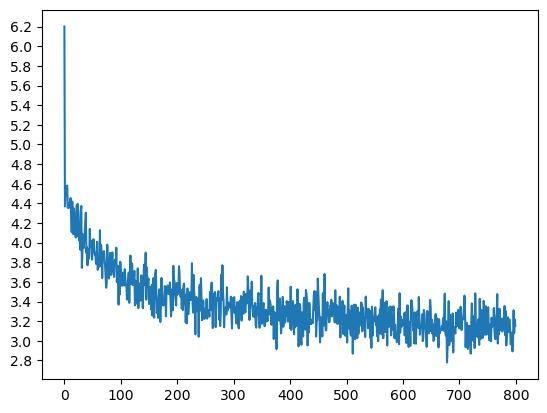

In [50]:
import matplotlib.pyplot as plt
plt.switch_backend('agg')
import matplotlib.ticker as ticker
import numpy as np
%matplotlib inline

def showPlot(points, file_name="spicy1_training_loss_plot.png"):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)
    plt.show()

showPlot(plot_losses)

In [41]:
%pip install bert_score

Note: you may need to restart the kernel to use updated packages.


In [42]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from bert_score import score

nltk.download('wordnet')
nltk.download('omw-1.4')

def compute_metrics(ref, hyp):
    ref_tokens = word_tokenize(ref.lower())
    hyp_tokens = word_tokenize(hyp.lower())
    smoothie = SmoothingFunction().method4
    bleu4 = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
    meteor = meteor_score([ref_tokens], hyp_tokens)
    return bleu4, meteor

def evaluate_on_dataset(encoder, decoder, data_pairs, max_length=100):
    total_bleu = 0.0
    total_meteor = 0.0
    all_preds = []
    all_golds = []
    for ingre, gold in data_pairs:
        pred_words = evaluate(encoder, decoder, ingre)
        if "<EOS>" in pred_words:
            pred_words = pred_words[:pred_words.index("<EOS>")]
        pred_sentence = ' '.join(pred_words)
        bleu, meteor = compute_metrics(gold, pred_sentence)
        total_bleu += bleu
        total_meteor += meteor
        all_preds.append(pred_sentence)
        all_golds.append(gold)

    mean_bleu = total_bleu / len(data_pairs)
    mean_meteor = total_meteor / len(data_pairs)

    P, R, F1 = score(all_preds, all_golds, lang='en', verbose=False)
    mean_bert = F1.mean().item()
    print(f"Testset Average BLEU-4 Score: {mean_bleu:.4f}")
    print(f"Testset Average METEOR Score: {mean_meteor:.4f}")
    print(f"Testset Average BERTScore (F1): {mean_bert:.4f}")
    return mean_bleu, mean_meteor, mean_bert


[nltk_data] Downloading package wordnet to /Users/kaichen/nltk_data...
[nltk_data] Downloading package omw-1.4 to /Users/kaichen/nltk_data...


In [43]:
def restore_trained_pipeline(path=CHECKPOINT_PATH):
    global encoder1, decoder1, input_lang, output_lang, hidden_size
    encoder1, decoder1, input_lang, output_lang, checkpoint = load_checkpoint(path, map_location=device)
    hidden_size = checkpoint["hidden_size"]
    print(f"Loaded checkpoint from {path}")
    print(f"best_dev_loss={checkpoint['best_dev_loss']}")
    print(f"epoch={checkpoint['epoch']}")
    return checkpoint

def prepareRecipeDataTest(csv_path):
    pairs = readRecipePairs(csv_path)
    pairs = filterPairs(pairs)
    print("Read %s samples" % len(pairs))
    print("Training input vocabulary: ", input_lang.n_words)
    print("Training output vocabulary: ", output_lang.n_words)
    return pairs

In [44]:
test_pairs = prepareRecipeDataTest("test.csv")
evaluate_on_dataset(encoder1, decoder1, test_pairs)

Read 755 samples
Training input vocabulary:  6651
Training output vocabulary:  10038


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Testset Average BLEU-4 Score: 0.0586
Testset Average METEOR Score: 0.2415
Testset Average BERTScore (F1): 0.8535


(0.05860786308563227, 0.24146146883399366, 0.8535243272781372)

In [ ]:
import csv

def generate_recipe(ing_list):
    with torch.no_grad():
        out = evaluate(encoder1, decoder1, ing_list)
    if out and out[-1] == '<EOS>':
        out = out[:-1]
    return ' '.join(out)

results = []
for item in test_pairs:
    ing_list = item[0]  
    pred_recipe = generate_recipe(ing_list)
    results.append((ing_list, pred_recipe))


output_path = "test_with_preds_model5_moff.tsv"
with open(output_path, 'w', encoding='utf-8', newline='') as f:
    writer = csv.writer(f, delimiter='\t')
    writer.writerow(['Ingredients', 'GeneratedRecipe'])
    for ing_list, pred_recipe in results:
        writer.writerow([str(ing_list), pred_recipe])

print("Done! Output is save at: ", output_path)

Done! Output is save at:  test_with_preds_model5_moff.tsv
